In [ ]:
!wget https://vision.middlebury.edu/stereo/data/scenes2021/zip/ambient-artroom.zip
!unzip -q ambient-artroom.zip
!rm ambient-artroom.zip

--2026-05-03 20:20:45--  https://vision.middlebury.edu/stereo/data/scenes2021/zip/ambient-artroom.zip
Resolving vision.middlebury.edu (vision.middlebury.edu)... 140.233.20.14
Connecting to vision.middlebury.edu (vision.middlebury.edu)|140.233.20.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 164556244 (157M) [application/zip]
Saving to: ‘ambient-artroom.zip’

ambient-artroom.zip 100%[===================>] 156.93M  43.2MB/s    in 4.2s    

2026-05-03 20:20:49 (37.8 MB/s) - ‘ambient-artroom.zip’ saved [164556244/164556244]



In [ ]:
!pip install numpy matplotlib pillow open3d -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 23.4 MB/s eta 0:00:00


In [ ]:
import numpy as np

# cam vars are the focal lens and certain sensor values

cam0 = np.array([[1733.74, 0, 792.27],
                 [0, 1733.74, 541.89],
                 [0, 0, 1]])

cam1 = np.array([[1733.74, 0, 792.27],
                 [0, 1733.74, 541.89],
                 [0, 0, 1]])

doffs=0 # the optical centers are perfectly horizontally aligned
baseline=536.62 # Distance between the two camera centers mm
width=1920 # image width
height=1080 # img height
ndisp=170 # number of disparity shifts to try between 0 and 170
vmin=55 # value of disparity that should be the farthest
vmax=142 # value of disparity that should be the closest

left shape: (1080, 1920)
right shape: (1080, 1920)


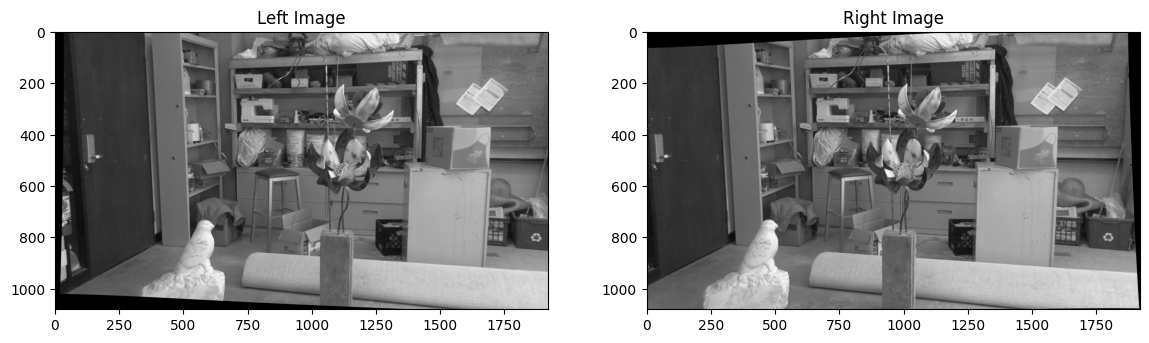

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# load images
left  = np.array(Image.open("data/artroom1/ambient/L0/im0e1.png").convert("L"))
right = np.array(Image.open("data/artroom1/ambient/L0/im1e1.png").convert("L"))

# quick sanity check
print("left shape:", left.shape)
print("right shape:", right.shape)

# display side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(left, cmap="gray")
ax1.set_title("Left Image")
ax2.imshow(right, cmap="gray")
ax2.set_title("Right Image")

plt.show()

Running OpenCV SGBM...


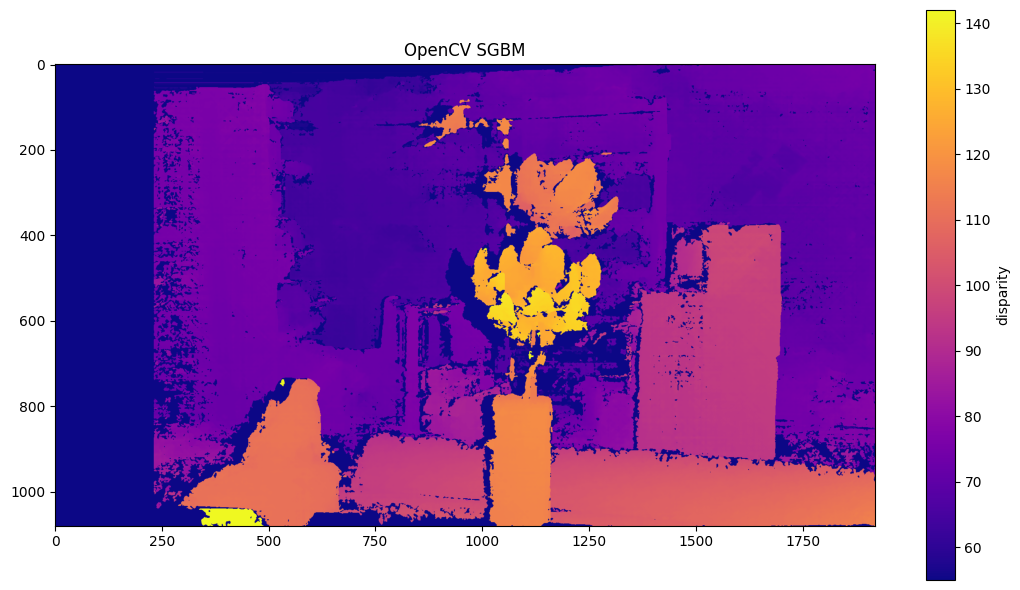

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("Running OpenCV SGBM...")
stereo = cv2.StereoSGBM_create(
    minDisparity=vmin,
    numDisparities=int(np.ceil(ndisp / 16)) * 16, # has to be divisible by 16
    blockSize=5,
    P1=8  * 3 * 5**2,
    P2=32 * 3 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32
)
disp_opencv = stereo.compute(left, right).astype(np.float32) / 16.0

disp_display = np.clip(disp_opencv, vmin, vmax)

plt.figure(figsize=(11, 6))
plt.imshow(disp_display, cmap='plasma', vmin=vmin, vmax=vmax)
plt.colorbar(label='disparity')
plt.title("OpenCV SGBM")
plt.tight_layout()
plt.show()

In [ ]:
focal_length = cam0[0, 0]  # 1733.74
cx = cam0[0, 2]            # 792.27
cy = cam0[1, 2]            # 541.89

Q = np.array([
    [1, 0,  0,              -cx],
    [0, 1,  0,              -cy],
    [0, 0,  0,     focal_length],
    [0, 0,  1/baseline,        0]   # +1/baseline, not -1/baseline
])

points_3d = cv2.reprojectImageTo3D(disp_opencv, Q)

In [ ]:
import plotly.graph_objects as go
import numpy as np

left_color = np.array(Image.open("data/artroom1/ambient/L0/im0e1.png").convert("RGB"))

points = points_3d.reshape(-1, 3)
colors = left_color.reshape(-1, 3) / 255.0

mask = np.isfinite(points[:, 2]) & (points[:, 2] > 0) & (points[:, 2] < 100000)
points = points[mask]
colors = colors[mask]

n = len(points)
idx = np.random.choice(n, size=min(50000, n), replace=False)
pts = points[idx]
cols = colors[idx]

color_strs = ['rgb({},{},{})'.format(int(r*255), int(g*255), int(b*255))
              for r, g, b in cols]

fig = go.Figure(data=[go.Scatter3d(
    x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
    mode='markers',
    marker=dict(size=1.5, color=color_strs, opacity=0.8)
)])

fig.update_layout(
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        yaxis=dict(),
        aspectmode='data'
    ),
    width=900, height=700,
    margin=dict(l=0, r=0, t=0, b=0)
)
fig.show()